In [2]:
import pandas as pd

In [6]:
df=pd.read_csv("raw_sales_data.csv")

In [7]:
df

,Order_ID,Order_Date,Category,Price,Quantity,Total_Spent,Customer_Segment
0,ORD1000,2026-02-08,Electronics,379.75,1,379.75,Consumer
1,ORD1001,2026-02-21,Clothing,46.77,2,93.55,Consumer
2,ORD1002,2026-01-29,Home & Kitchen,119.94,1,119.94,Corporate
3,ORD1003,2026-01-15,Home & Kitchen,101.15,2,202.30,Consumer
4,ORD1004,2026-02-12,Home & Kitchen,137.76,4,551.03,Corporate
...,...,...,...,...,...,...,...
145,ORD1145,2026-01-07,Clothing,45.27,1,45.27,Home Office
146,ORD1146,2026-01-09,Sports,72.76,2,145.53,Consumer
147,ORD1147,2026-01-08,Clothing,43.27,1,43.27,Consumer
148,ORD1148,2026-01-12,Clothing,48.99,2,97.98,Corporate


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
%matplotlib inline
sns.set_theme(style="whitegrid")

In [18]:
df = pd.read_csv("raw_sales_data.csv")

In [19]:
print("--- Dataset Info ---")
df.info()
print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          150 non-null    object 
 1   Order_Date        150 non-null    object 
 2   Category          150 non-null    object 
 3   Price             142 non-null    float64
 4   Quantity          150 non-null    int64  
 5   Total_Spent       150 non-null    float64
 6   Customer_Segment  137 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 8.3+ KB

--- Missing Values ---
Order_ID             0
Order_Date           0
Category             0
Price                8
Quantity             0
Total_Spent          0
Customer_Segment    13
dtype: int64


In [20]:
df.drop_duplicates(subset=['Order_ID'], keep='first', inplace=True)

In [21]:
df = df[df['Quantity'] > 0]

In [23]:
df['Price'] = df.groupby('Category')['Price'].transform(lambda x: x.fillna(x.median()))

In [22]:
df

,Order_ID,Order_Date,Category,Price,Quantity,Total_Spent,Customer_Segment
0,ORD1000,2026-02-08,Electronics,379.75,1,379.75,Consumer
1,ORD1001,2026-02-21,Clothing,46.77,2,93.55,Consumer
2,ORD1002,2026-01-29,Home & Kitchen,119.94,1,119.94,Corporate
3,ORD1003,2026-01-15,Home & Kitchen,101.15,2,202.30,Consumer
4,ORD1004,2026-02-12,Home & Kitchen,137.76,4,551.03,Corporate
...,...,...,...,...,...,...,...
145,ORD1145,2026-01-07,Clothing,45.27,1,45.27,Home Office
146,ORD1146,2026-01-09,Sports,72.76,2,145.53,Consumer
147,ORD1147,2026-01-08,Clothing,43.27,1,43.27,Consumer
148,ORD1148,2026-01-12,Clothing,48.99,2,97.98,Corporate


In [24]:
df['Total_Spent'] = df['Price'] * df['Quantity']

In [26]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Detect and remove extreme revenue outliers using the Interquartile Range (IQR)
Q1 = df['Total_Spent'].quantile(0.25)
Q3 = df['Total_Spent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the dataframe to keep only valid, non-outlier rows
df_clean = df[(df['Total_Spent'] >= lower_bound) & (df['Total_Spent'] <= upper_bound)].copy()

print(f"Original shape: {df.shape}, Cleaned shape: {df_clean.shape}")

Original shape: (144, 7), Cleaned shape: (134, 7)


In [27]:
df

,Order_ID,Order_Date,Category,Price,Quantity,Total_Spent,Customer_Segment
0,ORD1000,2026-02-08,Electronics,379.75,1,379.75,Consumer
1,ORD1001,2026-02-21,Clothing,46.77,2,93.54,Consumer
2,ORD1002,2026-01-29,Home & Kitchen,119.94,1,119.94,Corporate
3,ORD1003,2026-01-15,Home & Kitchen,101.15,2,202.30,Consumer
4,ORD1004,2026-02-12,Home & Kitchen,137.76,4,551.04,Corporate
...,...,...,...,...,...,...,...
145,ORD1145,2026-01-07,Clothing,45.27,1,45.27,Home Office
146,ORD1146,2026-01-09,Sports,72.76,2,145.52,Consumer
147,ORD1147,2026-01-08,Clothing,43.27,1,43.27,Consumer
148,ORD1148,2026-01-12,Clothing,48.99,2,97.98,Corporate


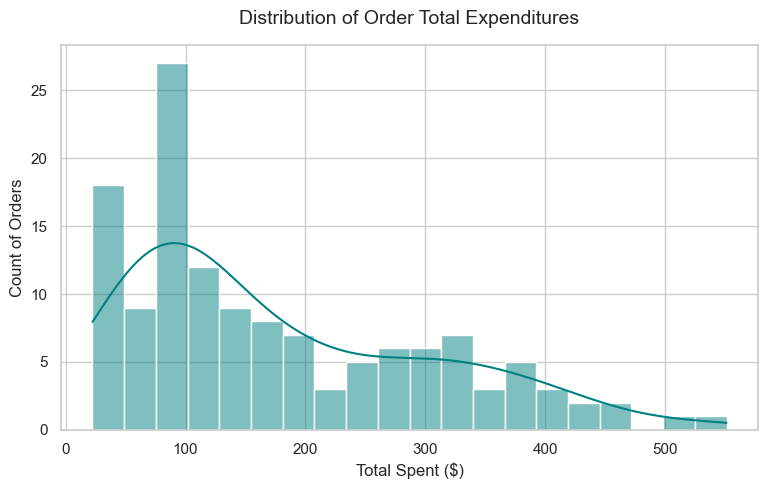

In [28]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df_clean, x='Total_Spent', kde=True, color='teal', bins=20)
plt.title('Distribution of Order Total Expenditures', fontsize=14, pad=15)
plt.xlabel('Total Spent ($)')
plt.ylabel('Count of Orders')
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_16896\3993289668.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='Total_Spent', y='Category', palette='Blues_r')


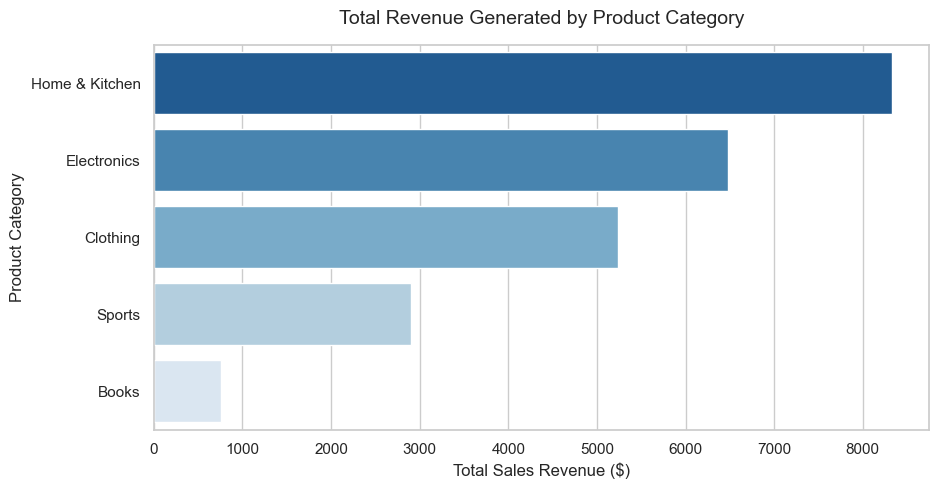

In [29]:
plt.figure(figsize=(10, 5))
# Aggregate revenue per category
category_sales = df_clean.groupby('Category')['Total_Spent'].sum().reset_index().sort_values(by='Total_Spent', ascending=False)

sns.barplot(data=category_sales, x='Total_Spent', y='Category', palette='Blues_r')
plt.title('Total Revenue Generated by Product Category', fontsize=14, pad=15)
plt.xlabel('Total Sales Revenue ($)')
plt.ylabel('Product Category')
plt.show()

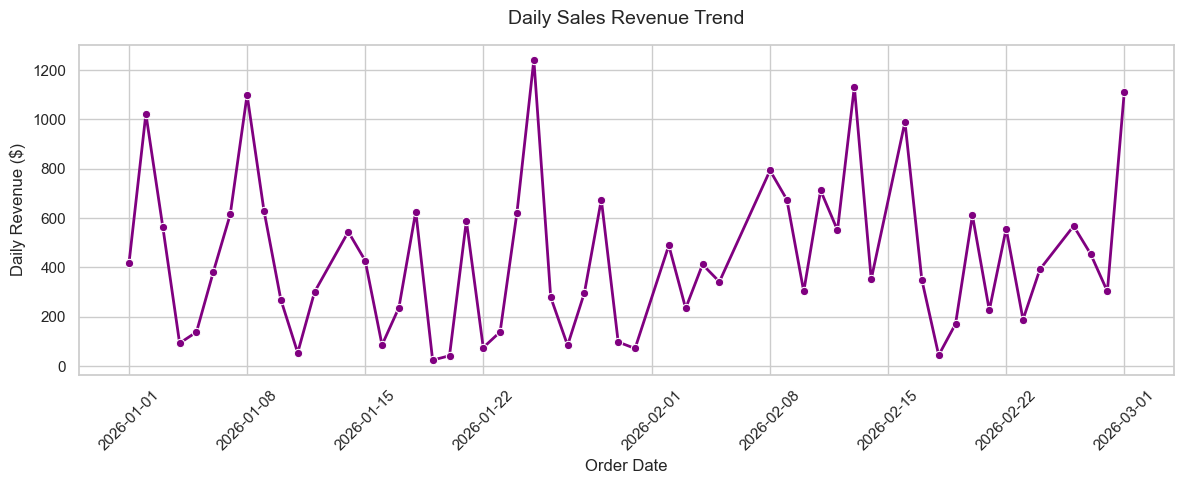

In [30]:
plt.figure(figsize=(12, 5))
# Aggregate revenue by order date
daily_sales = df_clean.groupby('Order_Date')['Total_Spent'].sum().reset_index()

sns.lineplot(data=daily_sales, x='Order_Date', y='Total_Spent', marker='o', color='purple', linewidth=2)
plt.title('Daily Sales Revenue Trend', fontsize=14, pad=15)
plt.xlabel('Order Date')
plt.ylabel('Daily Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_16896\1190837734.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Customer_Segment', y='Price', palette='Set2')


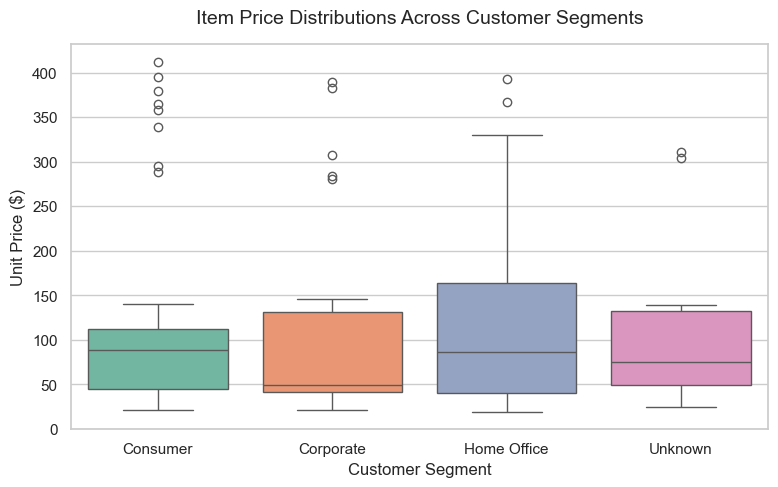

In [31]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_clean, x='Customer_Segment', y='Price', palette='Set2')
plt.title('Item Price Distributions Across Customer Segments', fontsize=14, pad=15)
plt.xlabel('Customer Segment')
plt.ylabel('Unit Price ($)')
plt.show()